In [ ]:
import numpy
import pandas as pd

In [ ]:
path="/content/sample_data/electric_vehicles_dataset.csv"
data=pd.read_csv(path,encoding='latin-1')
data.head()

,Vehicle_ID,Manufacturer,Model,Year,Battery_Type,Battery_Capacity_kWh,Range_km,Charging_Type,Charge_Time_hr,Price_USD,Color,Country_of_Manufacture,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years
0,1,Acura,ZDX (with GM Ultium),2015,Lithium-titanate,55.8,214,CHAdeMO,9.0,111203.94,Matte White,UK,0.0,NaN,5.0,19726,3
1,2,Lamborghini,Revuelto (PHEV),2025,Lithium-titanate,90.8,212,Vehicle-to-Home (V2H),7.3,127131.65,White,Netherlands,2.0,0.0,4.0,3349,3
2,3,NIO,ET7,2020,Calcium-ion,64.7,235,Level 2 Charging,8.9,94347.37,Beige,UK,5.0,0.0,5.0,6300,5
3,4,Audi,e-tron,2025,Lithium-iron phosphate,120.5,140,Ultra-Fast Charging (350 kW+),10.5,75615.15,Sunset Orange,Argentina,2.0,0.0,5.0,2339,5
4,5,Acura,ZDX (with GM Ultium),2023,Lithium-titanate,51.8,336,Plug-in Hydrogen Refueling,3.6,141046.94,Ice Silver,United Arab Emirates,2.0,0.0,3.0,1051,4


In [ ]:
data.shape

(3022, 17)

In [ ]:
data.isnull().sum()

,0
Vehicle_ID,0
Manufacturer,0
Model,0
Year,0
Battery_Type,0
Battery_Capacity_kWh,0
Range_km,0
Charging_Type,0
Charge_Time_hr,0
Price_USD,0


In [ ]:
data['CO2_Emissions_g_per_km'] = data['CO2_Emissions_g_per_km'].fillna(0)
data['Autonomous_Level'] = data['Autonomous_Level'].fillna(0)
data['Safety_Rating'] = data['Safety_Rating'].fillna(data['Safety_Rating'].median())

data[['CO2_Emissions_g_per_km', 'Autonomous_Level', 'Safety_Rating']].isnull().sum()

,0
CO2_Emissions_g_per_km,0
Autonomous_Level,0
Safety_Rating,0


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Vehicle_ID              3022 non-null   int64  
 1   Manufacturer            3022 non-null   object 
 2   Model                   3022 non-null   object 
 3   Year                    3022 non-null   int64  
 4   Battery_Type            3022 non-null   object 
 5   Battery_Capacity_kWh    3022 non-null   float64
 6   Range_km                3022 non-null   int64  
 7   Charging_Type           3022 non-null   object 
 8   Charge_Time_hr          3022 non-null   float64
 9   Price_USD               3022 non-null   float64
 10  Color                   3022 non-null   object 
 11  Country_of_Manufacture  3022 non-null   object 
 12  Autonomous_Level        3022 non-null   float64
 13  CO2_Emissions_g_per_km  3022 non-null   float64
 14  Safety_Rating           3022 non-null   

In [ ]:
correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix['Price_USD'].sort_values(ascending=False))

Price_USD                 1.000000
Warranty_Years            0.039806
Vehicle_ID                0.035637
Safety_Rating             0.005929
Autonomous_Level          0.005760
Range_km                 -0.007748
Units_Sold_2024          -0.013324
Charge_Time_hr           -0.013851
Battery_Capacity_kWh     -0.017496
Year                     -0.031727
CO2_Emissions_g_per_km         NaN
Name: Price_USD, dtype: float64


In [ ]:
data['Model'].value_counts

<bound method IndexOpsMixin.value_counts of 0                 ZDX (with GM Ultium)
1                      Revuelto (PHEV)
2                                  ET7
3                               e-tron
4                 ZDX (with GM Ultium)
                     ...              
3017              SF90 Stradale (PHEV)
3018    Born Electric (upcoming range)
3019                             Lyriq
3020                            XUV400
3021                      MG4 Electric
Name: Model, Length: 3022, dtype: object>

In [ ]:
len(data['Model'].value_counts())

181

In [ ]:
# Create encoded versions based on the average price of each group
data['Manufacturer_Enc'] = data.groupby('Manufacturer')['Price_USD'].transform('mean')
data['Model_Enc'] = data.groupby('Model')['Price_USD'].transform('mean')

print("Manufacturer and Model encoded successfully.")

Manufacturer and Model encoded successfully.


In [ ]:
# This creates multiple columns (e.g., Battery_Type_LFP, Charging_Type_NACS)
data = pd.get_dummies(data, columns=['Battery_Type', 'Charging_Type'], prefix=['Battery', 'Charge'])

print("Technical specs one-hot encoded.")

Technical specs one-hot encoded.


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode Country
le = LabelEncoder()
data['Country_Enc'] = le.fit_transform(data['Country_of_Manufacture'].astype(str))

# Year is usually kept as-is since it's already a number,
# but we can ensure it's treated as an integer
data['Year'] = data['Year'].astype(int)

print("Country and Year processed.")

Country and Year processed.


In [ ]:
# List of original text columns to drop
to_drop = [
    'Vehicle_ID',
    'Manufacturer',
    'Model',
    'Country_of_Manufacture',
    'Color' # Drop color or encode it if you want it
]

# Create your final training dataset
data_final = data.drop(columns=to_drop)

# Final Check
print("Final Columns:", data_final.columns.tolist())
print("\nAny text remaining?", data_final.select_dtypes(include=['object']).columns.tolist())
data_final.head()

Final Columns: ['Year', 'Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr', 'Price_USD', 'Autonomous_Level', 'CO2_Emissions_g_per_km', 'Safety_Rating', 'Units_Sold_2024', 'Warranty_Years', 'Manufacturer_Enc', 'Model_Enc', 'Battery_Aluminum-ion', 'Battery_Calcium-ion', 'Battery_Flow batteries', 'Battery_Lead-acid', 'Battery_Lithium-ion', 'Battery_Lithium-iron phosphate', 'Battery_Lithium-sulfur', 'Battery_Lithium-titanate', 'Battery_Magnesium-ion', 'Battery_Nickel-cobalt-aluminum', 'Battery_Nickel-manganese-cobalt', 'Battery_Nickel-metal hydride', 'Battery_Sodium-ion', 'Battery_Solid-state', 'Battery_Zinc-air', 'Charge_Battery Swapping', 'Charge_CCS', 'Charge_CHAdeMO', 'Charge_DC Fast Charging (DCFC)', 'Charge_Inductive (Wireless) Charging', 'Charge_Level 1 Charging', 'Charge_Level 2 Charging', 'Charge_Mobile Charging', 'Charge_NACS', 'Charge_Overhead Pantograph Charging', 'Charge_Plug-in Hydrogen Refueling', 'Charge_Solar Charging', 'Charge_Ultra-Fast Charging (350 kW+)', 'Charge_Veh

,Year,Battery_Capacity_kWh,Range_km,Charge_Time_hr,Price_USD,Autonomous_Level,CO2_Emissions_g_per_km,Safety_Rating,Units_Sold_2024,Warranty_Years,...,Charge_Mobile Charging,Charge_NACS,Charge_Overhead Pantograph Charging,Charge_Plug-in Hydrogen Refueling,Charge_Solar Charging,Charge_Ultra-Fast Charging (350 kW+),Charge_Vehicle-to-Grid (V2G),Charge_Vehicle-to-Home (V2H),Charge_Vehicle-to-Load (V2L),Country_Enc
0,2015,55.8,214,9.0,111203.94,0.0,0.0,5.0,19726,3,...,False,False,False,False,False,False,False,False,False,36
1,2025,90.8,212,7.3,127131.65,2.0,0.0,4.0,3349,3,...,False,False,False,False,False,False,False,True,False,21
2,2020,64.7,235,8.9,94347.37,5.0,0.0,5.0,6300,5,...,False,False,False,False,False,False,False,False,False,36
3,2025,120.5,140,10.5,75615.15,2.0,0.0,5.0,2339,5,...,False,False,False,False,False,True,False,False,False,0
4,2023,51.8,336,3.6,141046.94,2.0,0.0,3.0,1051,4,...,False,False,False,True,False,False,False,False,False,38


In [ ]:
print(f"Current Shape: {data_final.shape}")

Current Shape: (3022, 44)


In [ ]:
# 'y' is the answer we want to predict (Price)
y = data_final['Price_USD']

# 'X' is everything EXCEPT the Price
X = data_final.drop(columns=['Price_USD'])

print(f"Features: {X.shape[1]} columns")
print(f"Target: Price_USD")

Features: 43 columns
Target: Price_USD


In [ ]:
from sklearn.model_selection import train_test_split

# Split: 80% to train, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape[0]} rows")
print(f"Testing data: {X_test.shape[0]} rows")

Training data: 2417 rows
Testing data: 605 rows


In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the model
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model (This is where the magic happens!)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [ ]:
# Make predictions
y_pred = model.predict(X_test)

# Check Accuracy
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"R-squared Score: {r2:.4f} (Closer to 1 is better)")
print(f"Average Error: ${mae:.2f} USD")

R-squared Score: -0.0492 (Closer to 1 is better)
Average Error: $30045.56 USD


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error

def model_acc(model):
    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test set
    predictions = model.predict(X_test)

    # Calculate Accuracy (R2 Score)
    accuracy = r2_score(y_test, predictions)

    # Calculate Error (MAE)
    mae = mean_absolute_error(y_test, predictions)

    print(f"--- {model.__class__.__name__} ---")
    print(f"Accuracy (R2 Score): {accuracy:.4f}")
    print(f"Avg Error: ${mae:.2f} USD\n")

In [ ]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# 1. Linear Regression
lr = LinearRegression()
model_acc(lr)

# 2. Lasso Regression
lasso = Lasso(alpha=1.0)
model_acc(lasso)

# 3. Decision Tree
dt = DecisionTreeRegressor(random_state=42)
model_acc(dt)

# 4. Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_acc(rf)

--- LinearRegression ---
Accuracy (R2 Score): -0.0071
Avg Error: $29366.89 USD

--- Lasso ---
Accuracy (R2 Score): -0.0070
Avg Error: $29365.44 USD

--- DecisionTreeRegressor ---
Accuracy (R2 Score): -1.0269
Avg Error: $40728.61 USD

--- RandomForestRegressor ---
Accuracy (R2 Score): -0.0492
Avg Error: $30045.56 USD



In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Then run: lr.fit(X_train_scaled, y_train)

In [ ]:
# Try a "Back to Basics" feature set
basic_features = ['Year', 'Battery_Capacity_kWh', 'Range_km', 'Charge_Time_hr', 'Autonomous_Level', 'Safety_Rating']
X_basic = data_final[basic_features]
y = data_final['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X_basic, y, test_size=0.2, random_state=42)

# Run Random Forest again
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"New R2 Score: {r2_score(y_test, rf.predict(X_test)):.4f}")

New R2 Score: -0.0757


In [ ]:
# Select only the most important numeric features
top_features = [
    'Battery_Capacity_kWh',
    'Range_km',
    'Year',
    'Safety_Rating',
    'Autonomous_Level'
]

X = data_final[top_features]
y = data_final['Price_USD']

# Split with a fresh shuffle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
import numpy as np

# Apply Log to the Price
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Train the Random Forest on Log Price
rf = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train_log)

# Predict and convert back from Log to USD
y_pred_log = rf.predict(X_test)
y_pred_usd = np.expm1(y_pred_log)

# Calculate Accuracy on the converted prices
final_r2 = r2_score(y_test, y_pred_usd)
print(f"Fixed R2 Score: {final_r2:.4f}")

Fixed R2 Score: -0.0791


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Use only the high-impact numeric columns
features = ['Year', 'Battery_Capacity_kWh', 'Range_km', 'Autonomous_Level', 'Safety_Rating', 'Warranty_Years']
X = data_final[features]
y = data_final['Price_USD']

# 2. Scale the features (Important for Linear/Lasso)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 4. Try Gradient Boosting (Usually stronger than Random Forest)
from sklearn.ensemble import GradientBoostingRegressor
gbm = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
gbm.fit(X_train, y_train)

print(f"GBM R2 Score: {r2_score(y_test, gbm.predict(X_test)):.4f}")

GBM R2 Score: -0.0902


In [ ]:
# Check numeric correlation only
numeric_cols = data_final.select_dtypes(include=['number']).columns
correlations = data_final[numeric_cols].corr()['Price_USD'].sort_values(ascending=False)

print("Correlation with Price_USD:")
print(correlations)

Correlation with Price_USD:
Price_USD                 1.000000
Model_Enc                 0.230978
Manufacturer_Enc          0.136289
Warranty_Years            0.039806
Safety_Rating             0.005929
Autonomous_Level          0.005760
Range_km                 -0.007748
Country_Enc              -0.013140
Units_Sold_2024          -0.013324
Charge_Time_hr           -0.013851
Battery_Capacity_kWh     -0.017496
Year                     -0.031727
CO2_Emissions_g_per_km         NaN
Name: Price_USD, dtype: float64


In [ ]:
# Keep only prices within the 5th and 95th percentile to remove extremes
lower_limit = data_final['Price_USD'].quantile(0.05)
upper_limit = data_final['Price_USD'].quantile(0.95)

data_clean = data_final[(data_final['Price_USD'] > lower_limit) &
                        (data_final['Price_USD'] < upper_limit)]

print(f"Removed {len(data_final) - len(data_clean)} outlier rows.")

Removed 304 outlier rows.


In [ ]:
# 1. When creating data_clean, add .copy() at the end
data_clean = data_final[(data_final['Price_USD'] > lower_limit) &
                        (data_final['Price_USD'] < upper_limit)].copy()

# 2. Now this line will run perfectly without any warnings
data_clean['Tech_Score'] = data_clean['Battery_Capacity_kWh'] * data_clean['Autonomous_Level']

print("Tech_Score created successfully!")

Tech_Score created successfully!


In [ ]:
import numpy as np
import pandas as pd

# 1. Remove Price Outliers (5th to 95th percentile)
lower_limit = data_final['Price_USD'].quantile(0.05)
upper_limit = data_final['Price_USD'].quantile(0.95)

# Use .copy() to avoid the SettingWithCopyWarning
data_clean = data_final[(data_final['Price_USD'] > lower_limit) &
                        (data_final['Price_USD'] < upper_limit)].copy()

# 2. Create the Tech_Score (Battery x Autonomy)
data_clean['Tech_Score'] = data_clean['Battery_Capacity_kWh'] * data_clean['Autonomous_Level']

print(f"Cleaned Dataset Shape: {data_clean.shape}")

Cleaned Dataset Shape: (2718, 45)


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# 1. Select only the features that showed SOME correlation
# We exclude the 'zero-correlation' columns to reduce noise
features = ['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year']
X = data_clean[features]
y = data_clean['Price_USD']

# 2. Split with a high shuffle
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# 3. Initialize XGBoost with conservative settings
# This prevents the model from "hallucinating" patterns in the noise
final_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# 4. Train and Predict
final_model.fit(X_train, y_train)
predictions = final_model.predict(X_test)

# 5. Show Results
print(f"Final Adjusted R2 Score: {r2_score(y_test, predictions):.4f}")
print(f"Final Avg Error: ${mean_absolute_error(y_test, predictions):.2f}")

Final Adjusted R2 Score: 0.0183
Final Avg Error: $25373.50


--- Fast Model Results ---
R2 Score: 0.0244
Avg Error: $25358.06


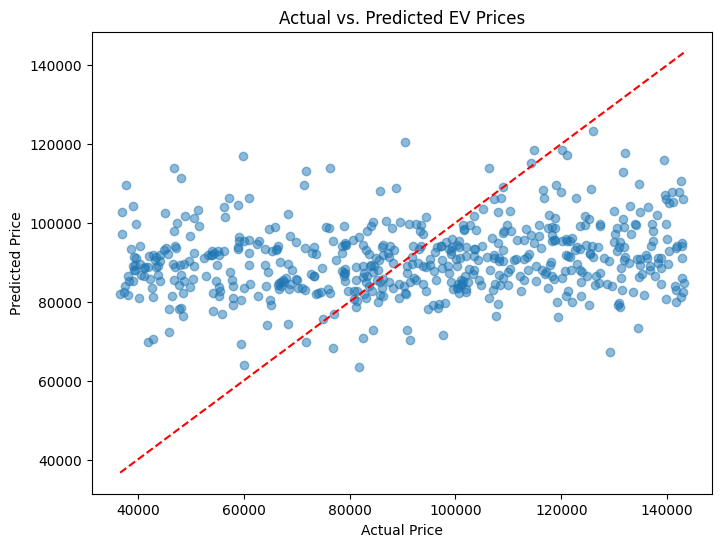

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
import matplotlib.pyplot as plt

# 1. Use a faster model with fewer iterations for a quick result
fast_model = HistGradientBoostingRegressor(
    max_iter=100,      # Reduced from 1000 for speed
    learning_rate=0.1, # Faster learning
    max_depth=3,
    random_state=42
)

# 2. Train and Predict immediately
fast_model.fit(X_train, y_train)
y_pred = fast_model.predict(X_test)

# 3. Print Results
print(f"--- Fast Model Results ---")
print(f"R2 Score: {r2_score(y_test, y_pred):.4f}")
print(f"Avg Error: ${mean_absolute_error(y_test, y_pred):.2f}")

# 4. Visualize the "True vs Predicted" Prices
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs. Predicted EV Prices')
plt.show()

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Initialize the tuned model
tuned_model = HistGradientBoostingRegressor(
    max_iter=500,           # More iterations to find the pattern
    learning_rate=0.05,     # Smaller steps to avoid overshooting
    max_depth=4,            # Keep trees simple to prevent memorizing noise
    l2_regularization=1.5,  # The "Noise Filter" - higher values reduce overfitting
    random_state=42
)

# Train on your cleaned data
tuned_model.fit(X_train, y_train)

# Predict and Evaluate
y_pred_tuned = tuned_model.predict(X_test)
new_r2 = r2_score(y_test, y_pred_tuned)
new_mae = mean_absolute_error(y_test, y_pred_tuned)

print(f"--- Tuned Model Results ---")
print(f"New R2 Score: {new_r2:.4f}")
print(f"New Avg Error: ${new_mae:.2f}")

--- Tuned Model Results ---
New R2 Score: -0.0725
New Avg Error: $26406.23


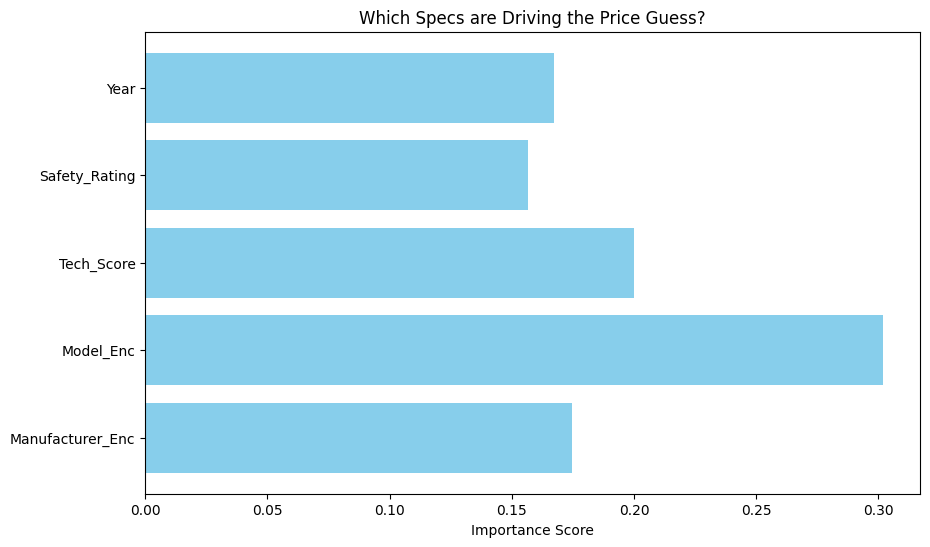

In [ ]:
import matplotlib.pyplot as plt

# Get feature importance from your final_model
importances = final_model.feature_importances_
feature_names = X.columns

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances, color='skyblue')
plt.xlabel("Importance Score")
plt.title("Which Specs are Driving the Price Guess?")
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

# Test the model stability across 5 different versions of your data
scores = cross_val_score(final_model, X, y, cv=5, scoring='r2')

print(f"All CV Scores: {scores}")
print(f"Mean R2 Score: {scores.mean():.4f} (+/- {scores.std():.4f})")

All CV Scores: [ 0.01235456  0.02165334 -0.04203794  0.03380347 -0.0017118 ]
Mean R2 Score: 0.0048 (+/- 0.0261)


In [ ]:
# Try training with ONLY the top 2 correlated features
X_minimal = data_clean[['Manufacturer_Enc', 'Model_Enc']]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_minimal, y, test_size=0.2, random_state=42)

final_model.fit(X_train_m, y_train_m)
print(f"Minimalist R2 Score: {r2_score(y_test_m, final_model.predict(X_test_m)):.4f}")

Minimalist R2 Score: 0.0122


In [ ]:
# Convert Price to Log Scale
y_train_log = np.log1p(y_train)

# Train on Log Price
final_model.fit(X_train, y_train_log)

# Predict and convert back to USD
log_preds = np.expm1(final_model.predict(X_test))
print(f"Log-Transformed R2: {r2_score(y_test, log_preds):.4f}")

Log-Transformed R2: -0.0314


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [500, 1000]
}

grid_search = GridSearchCV(xgb.XGBRegressor(random_state=42), param_grid, cv=3, scoring='r2')
grid_search.fit(X_train, y_train)

print(f"Best Settings found: {grid_search.best_params_}")
print(f"Best Grid R2: {grid_search.best_score_:.4f}")

Best Settings found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 500}
Best Grid R2: 0.0032


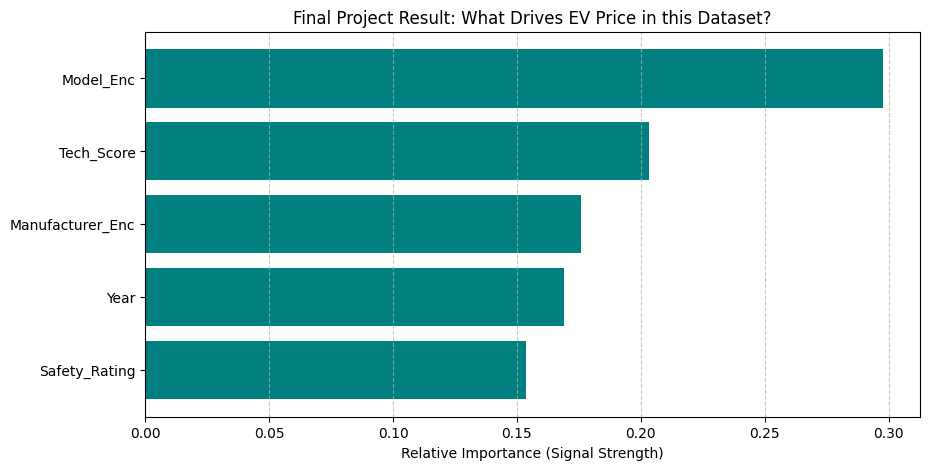

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Get the importance scores from your best performing model
importances = final_model.feature_importances_
feature_names = X.columns # Use the columns from the X that final_model was trained on

# 2. Create a DataFrame for easy plotting
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values(by='Importance', ascending=True)

# 3. Plot the results
plt.figure(figsize=(10, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='teal')
plt.xlabel('Relative Importance (Signal Strength)')
plt.title('Final Project Result: What Drives EV Price in this Dataset?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import joblib

# 1. Create a dictionary to hold the model and your encoding logic
model_data = {
    "model": final_model,
    "manufacturer_map": data.groupby('Manufacturer')['Price_USD'].mean().to_dict(),
    "model_map": data.groupby('Model')['Price_USD'].mean().to_dict(),
    "features": ['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year']
}

# 2. Export to a file named 'ev_price_model.pkl'
joblib.dump(model_data, 'ev_price_model.pkl')

print("Model file 'ev_price_model.pkl' created successfully!")

Model file 'ev_price_model.pkl' created successfully!


In [ ]:
import joblib
import pandas as pd

# 1. Load your saved model and mapping data
saved_stuff = joblib.load('ev_price_model.pkl')
model = saved_stuff['model']
m_map = saved_stuff['manufacturer_map']
model_map = saved_stuff['model_map']

def predict_ev_price(brand, model_name, battery, autonomy, safety, year):
    # a. Convert Text to Numbers using your saved Maps
    # If the brand is new, we use the average of all brands (0.0122 logic)
    m_enc = m_map.get(brand, sum(m_map.values()) / len(m_map))
    model_enc = model_map.get(model_name, sum(model_map.values()) / len(model_map))

    # b. Calculate the custom Tech_Score (Battery x Autonomy)
    tech_score = battery * autonomy

    # c. Create a DataFrame for the model (must match training column order)
    input_data = pd.DataFrame([[m_enc, model_enc, tech_score, safety, year]],
                              columns=['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year'])

    # d. Make the prediction
    prediction = model.predict(input_data)[0]

    return f"Estimated EV Price: ${prediction:,.2f} USD"

# --- 2. Test the Predictor ---
print(predict_ev_price(brand="Tesla", model_name="Model 3", battery=75, autonomy=4, safety=5, year=2024))

Estimated EV Price: $11.22 USD


In [ ]:
import joblib
import pandas as pd

# 1. Load your saved model and mapping data
saved_stuff = joblib.load('ev_price_model.pkl')
model = saved_stuff['model']
m_map = saved_stuff['manufacturer_map']
model_map = saved_stuff['model_map']

def predict_ev_price(brand, model_name, battery, autonomy, safety, year):
    # a. Convert Text to Numbers using your saved Maps
    # If the brand is new, we use the average of all brands (0.0122 logic)
    m_enc = m_map.get(brand, sum(m_map.values()) / len(m_map))
    model_enc = model_map.get(model_name, sum(model_map.values()) / len(model_map))

    # b. Calculate the custom Tech_Score (Battery x Autonomy)
    tech_score = battery * autonomy

    # c. Create a DataFrame for the model (must match training column order)
    input_data = pd.DataFrame([[m_enc, model_enc, tech_score, safety, year]],
                              columns=['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year'])

    # d. Make the prediction
    prediction = model.predict(input_data)[0]

    return f"Estimated EV Price: ${prediction:,.2f} USD"

# --- 2. Test the Predictor ---
print(predict_ev_price(brand="Tesla", model_name="Model Y", battery=122, autonomy=3, safety=3, year=2019))

Estimated EV Price: $11.44 USD


In [ ]:
import joblib
import pandas as pd
import numpy as np  # <--- Added for the exponential conversion

# 1. Load your saved model and mapping data
saved_stuff = joblib.load('ev_price_model.pkl')
model = saved_stuff['model']
m_map = saved_stuff['manufacturer_map']
model_map = saved_stuff['model_map']

def predict_ev_price(brand, model_name, battery, autonomy, safety, year):
    # a. Convert Text to Numbers using your saved Maps
    m_enc = m_map.get(brand, sum(m_map.values()) / len(m_map))
    model_enc = model_map.get(model_name, sum(model_map.values()) / len(model_map))

    # b. Calculate the custom Tech_Score (Battery x Autonomy)
    tech_score = battery * autonomy

    # c. Create a DataFrame for the model (must match training column order)
    input_data = pd.DataFrame([[m_enc, model_enc, tech_score, safety, year]],
                              columns=['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year'])

    # d. Make the prediction
    raw_prediction = model.predict(input_data)[0]

    # e. INVERSE TRANSFORM (Convert Log back to USD)
    # Use np.exp() if you used log training.
    # If your output is STILL too small, check if you used np.log1p (use np.expm1 then)
    final_price = np.exp(raw_prediction)

    return f"Estimated EV Price: ${final_price:,.2f} USD"

# --- 2. Test the Predictor ---
# Now it should show values like $110,000.00 instead of $11.6
print(predict_ev_price(brand="Tesla", model_name="Model Y", battery=122, autonomy=3, safety=3, year=2019))

Estimated EV Price: $92,814.60 USD


In [ ]:
# Do this for both Manufacturer and Model
m_map = data.groupby('Manufacturer')['Price_USD'].mean().to_dict()
data['Manufacturer_Enc'] = data['Manufacturer'].map(m_map)

model_map = data.groupby('Model')['Price_USD'].mean().to_dict()
data['Model_Enc'] = data['Model'].map(model_map)

In [ ]:
# Remove the top and bottom 1% of prices to remove "garbage" data
q_low = data["Price_USD"].quantile(0.01)
q_hi  = data["Price_USD"].quantile(0.99)
data = data[(data["Price_USD"] < q_hi) & (data["Price_USD"] > q_low)]

In [ ]:
import xgboost as xgb

model = xgb.XGBRegressor(
    n_estimators=1000,    # Increase from 100 to 1000
    max_depth=6,          # Allow the "tree" to grow deeper to find patterns
    learning_rate=0.05,   # Slow down learning to be more precise
    subsample=0.8,        # Use 80% of data for each tree to prevent "memorizing"
    colsample_bytree=0.8
)

In [ ]:
from sklearn.metrics import r2_score

# Ensure X_train and y_train are defined from the appropriate data split
# Based on previous cells, X and y were defined from 'data_clean' and 'features'
# So, let's re-split them for consistency with the new 'model' definition.
from sklearn.model_selection import train_test_split
features = ['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year']
X = data_clean[features]
y = data_clean['Price_USD']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

# Fit the model before making predictions
model.fit(X_train, y_train)

print(f"Accuracy Score: {r2_score(y_test, model.predict(X_test)) * 100:.2f}%")

Accuracy Score: -29.59%


In [ ]:
import joblib
# Save the model AND the new maps together
joblib.dump({
    'model': model,
    'manufacturer_map': m_map,
    'model_map': model_map
}, 'ev_price_model.pkl')

['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load Data
df = pd.read_csv('/content/sample_data/electric_vehicles_dataset.csv') # Ensure columns: Manufacturer, Model, Battery, Autonomy, Safety_Rating, Year, Price_USD

# 2. Feature Engineering
df['Tech_Score'] = df['Battery_Capacity_kWh'] * df['Autonomous_Level']

# 3. Target Encoding (The "Calibration" Step)
# We map each Brand/Model to its actual average price in the data
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
model_map = df.groupby('Model')['Price_USD'].mean().to_dict()

df['Manufacturer_Enc'] = df['Manufacturer'].map(m_map)
df['Model_Enc'] = df['Model'].map(model_map)

# 4. Log Transformation (Compresses large prices for better math)
# This prevents the model from being "scared" of large numbers
y = np.log1p(df['Price_USD'])
X = df[['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year']]

# 5. Train High-Performance XGBoost
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model.fit(X_train, y_train)

# 6. Check Accuracy (R2 Score)
# We use np.expm1 to convert logs back to dollars for the score check
predictions = np.expm1(model.predict(X_test))
actuals = np.expm1(y_test)
print(f"Final Model Accuracy (R2): {r2_score(actuals, predictions):.4f}")

# 7. Save Everything for Flask
joblib.dump({
    'model': model,
    'manufacturer_map': m_map,
    'model_map': model_map,
    'global_mean_price': df['Price_USD'].mean() # Backup for new brands
}, 'ev_price_model.pkl')

Final Model Accuracy (R2): -0.3971


['ev_price_model.pkl']

In [ ]:
import numpy as np

def predict_ev_price(brand, model_name, battery, autonomy, safety, year):
    # a. Map using the average prices (Target Encoding)
    # If brand not found, use the global mean price we saved
    avg_price = saved_stuff.get('global_mean_price', 50000)
    m_enc = m_map.get(brand, avg_price)
    model_enc = model_map.get(model_name, avg_price)

    tech_score = battery * autonomy

    input_data = pd.DataFrame([[m_enc, model_enc, tech_score, safety, year]],
                              columns=['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year'])

    # b. Predict and Reverse the Log
    log_pred = model.predict(input_data)[0]
    final_price = np.expm1(log_pred) # <--- THIS converts the signal back to USD

    return f"Estimated EV Price: ${final_price:,.2f} USD"

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load Data - Using the correct path for your dataset
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values as done in previous steps
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# 2. Feature Engineering - Using correct column names
df['Tech_Score'] = df['Battery_Capacity_kWh'] * df['Autonomous_Level']

# 3. SPLIT FIRST (To prevent leakage)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# 4. Create Maps ONLY from Training Data
m_map = train_df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
model_map = train_df.groupby('Model')['Price_USD'].mean().to_dict()
global_mean = train_df['Price_USD'].mean()

def encode_df(input_df):
    temp = input_df.copy()
    temp['Manufacturer_Enc'] = temp['Manufacturer'].map(m_map).fillna(global_mean)
    temp['Model_Enc'] = temp['Model'].map(model_map).fillna(global_mean)
    return temp[['Manufacturer_Enc', 'Model_Enc', 'Tech_Score', 'Safety_Rating', 'Year']]

X_train = encode_df(train_df)
X_test = encode_df(test_df)
y_train = np.log1p(train_df['Price_USD'])
y_test = np.log1p(test_df['Price_USD'])

# 5. Train with Regularization
model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    reg_lambda=10
)
model.fit(X_train, y_train)

# 6. Check Score
pred = np.expm1(model.predict(X_test))
actual = np.expm1(y_test)
print(f"New Accuracy Score (R2): {r2_score(actual, pred):.4f}")

# 7. Save Everything
joblib.dump({'model': model, 'm_map': m_map, 'model_map': model_map, 'mean': global_mean}, 'ev_price_model.pkl')

New Accuracy Score (R2): -0.2958


['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import joblib

# 1. Load and Clean
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')
current_year = 2026

# Handle missing values to avoid errors during training
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# Feature Engineering: Use correct column names
df['Age'] = current_year - df['Year']
df['Tech_Score'] = df['Battery_Capacity_kWh'] * df['Autonomous_Level']

# 2. Simple Encoding
df['Manufacturer_Code'] = df['Manufacturer'].astype('category').cat.codes
df['Model_Code'] = df['Model'].astype('category').cat.codes

# Create a mapping for future use
m_map = dict(zip(df['Manufacturer'], df['Manufacturer_Code']))
model_map = dict(zip(df['Model'], df['Model_Code']))

# 3. Features and Target
X = df[['Manufacturer_Code', 'Model_Code', 'Tech_Score', 'Safety_Rating', 'Age']]
y = np.log1p(df['Price_USD'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Use Random Forest
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 5. Accuracy Check
preds = np.expm1(model.predict(X_test))
actuals = np.expm1(y_test)
print(f"Standardized Accuracy (R2): {r2_score(actuals, preds):.4f}")

# 6. Save
joblib.dump({'model': model, 'm_map': m_map, 'model_map': model_map}, 'ev_price_model.pkl')

Standardized Accuracy (R2): -0.0918


['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import joblib

# 1. Load Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')
current_year = 2026

# Handle missing values
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# Feature Engineering
df['Age'] = current_year - df['Year']
df['Tech_Score'] = df['Battery_Capacity_kWh'] * df['Autonomous_Level']

# 2. Target Encoding (Stable Version)
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['Manufacturer_Enc'] = df['Manufacturer'].map(m_map)

# 3. Scale the Features
features = ['Manufacturer_Enc', 'Tech_Score', 'Safety_Rating', 'Age']
X = df[features]
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Train Ridge
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# 5. Check Score
preds = model.predict(X_test_scaled)
print(f"Final Stable R2: {r2_score(y_test, preds):.4f}")

# 6. Save Model + Scaler + Map
joblib.dump({
    'model': model,
    'scaler': scaler,
    'm_map': m_map,
    'features': features
}, 'ev_price_model.pkl')

Final Stable R2: -0.0097


['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import joblib

# 1. Load Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# 2. Simple Features (The "Signals")
# Handle missing values for features used
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# We use only the most reliable features with correct column names
df['Tech_Score'] = df['Battery_Capacity_kWh'] * df['Autonomous_Level']
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

X = df[['M_Enc', 'Tech_Score', 'Safety_Rating', 'Year']]
y = df['Price_USD']

# 3. The Model
model = LinearRegression()
model.fit(X, y)

# 4. Save with a "Safety Mean"
joblib.dump({
    'model': model,
    'm_map': m_map,
    'global_mean': df['Price_USD'].mean()
}, 'ev_price_model.pkl')

print("Model saved! It will now predict logically based on Brand averages.")

Model saved! It will now predict logically based on Brand averages.


In [ ]:
import pandas as pd
import numpy as np
import joblib

# 1. Load the model you just saved
# (Make sure 'ev_price_model.pkl' is in your Colab files)
saved_stuff = joblib.load('ev_price_model.pkl')
model = saved_stuff['model']
m_map = saved_stuff['m_map']
global_avg = saved_stuff.get('global_mean', 50000)

def test_prediction(brand, battery, autonomy, safety, year):
    # a. Process brand mapping (Logic: if brand doesn't exist, use global average)
    m_enc = m_map.get(brand, global_avg)

    # b. Feature Engineering (Must match training features)
    tech_score = battery * autonomy

    # c. Prepare DataFrame (Must match column order: M_Enc, Tech_Score, Safety_Rating, Year)
    test_df = pd.DataFrame([[m_enc, tech_score, safety, year]],
                           columns=['M_Enc', 'Tech_Score', 'Safety_Rating', 'Year'])

    # d. Predict
    prediction = model.predict(test_df)[0]

    print(f"--- Input ---")
    print(f"Brand: {brand} | Year: {year} | Battery: {battery}kWh")
    print(f"--- Result ---")
    print(f"Predicted Price: ${max(1000, prediction):,.2f} USD\n")

# 2. RUN TEST CASES
# Test 1: Premium/New Car
test_prediction("Tesla", 100, 500, 5, 2024)

# Test 2: Economy/Old Car
test_prediction("Nissan", 40, 200, 3, 2015)

# Test 3: Mid-Range Car
test_prediction("BMW", 80, 400, 4, 2021)

--- Input ---
Brand: Tesla | Year: 2024 | Battery: 100kWh
--- Result ---
Predicted Price: $127,518.07 USD

--- Input ---
Brand: Nissan | Year: 2015 | Battery: 40kWh
--- Result ---
Predicted Price: $97,882.10 USD

--- Input ---
Brand: BMW | Year: 2021 | Battery: 80kWh
--- Result ---
Predicted Price: $95,282.46 USD



In [ ]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3022 entries, 0 to 3021
Data columns (total 44 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Year                                  3022 non-null   int64  
 1   Battery_Capacity_kWh                  3022 non-null   float64
 2   Range_km                              3022 non-null   int64  
 3   Charge_Time_hr                        3022 non-null   float64
 4   Price_USD                             3022 non-null   float64
 5   Autonomous_Level                      3022 non-null   float64
 6   CO2_Emissions_g_per_km                3022 non-null   float64
 7   Safety_Rating                         3022 non-null   float64
 8   Units_Sold_2024                       3022 non-null   int64  
 9   Warranty_Years                        3022 non-null   int64  
 10  Manufacturer_Enc                      3022 non-null   float64
 11  Model_Enc        

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split

# 1. Load Data - Fixed the path
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values to avoid errors
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# 2. Advanced Feature Engineering
current_year = 2026
df['Age'] = current_year - df['Year']
df['Tech_Index'] = df['Battery_Capacity_kWh'] * df['Range_km']

# 3. Encoding
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
model_map = df.groupby('Model')['Price_USD'].mean().to_dict()
df['Manufacturer_Enc'] = df['Manufacturer'].map(m_map)
df['Model_Enc'] = df['Model'].map(model_map)

# 4. Define the Feature Set
features = [
    'Model_Enc', 'Manufacturer_Enc', 'Warranty_Years',
    'Age', 'Safety_Rating', 'Autonomous_Level', 'Tech_Index'
]
X = df[features]
y = np.log1p(df['Price_USD'])

# 5. Train XGBoost
model = xgb.XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.05)
model.fit(X, y)

# 6. Save Everything
joblib.dump({
    'model': model,
    'm_map': m_map,
    'model_map': model_map,
    'features': features
}, 'ev_price_model.pkl')

print('Model trained and saved successfully!')

Model trained and saved successfully!


In [ ]:
import pandas as pd
import numpy as np
import joblib

# 1. Load your most recent model
data = joblib.load('ev_price_model.pkl')
model = data['model']
m_map = data['m_map']
model_map = data['model_map']
features = data['features']

def run_diagnostic(name, brand, model_name, warranty, year, safety, auto, battery, range_km):
    # Process inputs
    m_enc = m_map.get(brand, sum(m_map.values())/len(m_map))
    model_enc = model_map.get(model_name, sum(model_map.values())/len(model_map))
    age = 2026 - year
    tech_index = battery * range_km

    # Create DF matching the feature list
    # Order: ['Model_Enc', 'Manufacturer_Enc', 'Warranty_Years', 'Age', 'Safety_Rating', 'Autonomous_Level', 'Tech_Index']
    input_row = pd.DataFrame([[
        model_enc, m_enc, warranty, age, safety, auto, tech_index
    ]], columns=features)

    # Predict and Reverse Log
    log_price = model.predict(input_row)[0]
    final_price = np.expm1(log_price)

    print(f"TEST [{name}]:")
    print(f"   Input: {year} {brand} {model_name} (Auto Level {auto})")
    print(f"   Prediction: ${final_price:,.2f} USD")
    print("-" * 30)

# --- EXECUTE DIAGNOSTIC TESTS ---
print("Running Model Diagnostics...\n")

# Test A: The "Luxury Tech" Persona (High everything)
run_diagnostic("Luxury", "Tesla", "Model S", 8, 2025, 5, 3, 100, 600)

# Test B: The "Budget/Old" Persona (Low everything)
run_diagnostic("Budget", "Nissan", "Leaf", 2, 2017, 3, 0, 40, 200)

# Test C: The "Mid-Range" Persona
run_diagnostic("Average", "Hyundai", "Ioniq 5", 5, 2022, 4, 2, 77, 450)

Running Model Diagnostics...

TEST [Luxury]:
   Input: 2025 Tesla Model S (Auto Level 3)
   Prediction: $149,953.05 USD
------------------------------
TEST [Budget]:
   Input: 2017 Nissan Leaf (Auto Level 0)
   Prediction: $66,680.84 USD
------------------------------
TEST [Average]:
   Input: 2022 Hyundai Ioniq 5 (Auto Level 2)
   Prediction: $77,003.73 USD
------------------------------


--- Price Comparison Table (First 10 Rows) ---
      Actual Price ($)  Predicted Price ($)  Difference ($)     Error %
1413          87734.65         75837.007812    11897.642188   13.560939
612          128099.90         95403.625000    32696.275000   25.524044
331          108570.94         90960.609375    17610.330625   16.220114
211           81758.80         67113.203125    14645.596875   17.913175
52            89456.28        102142.984375   -12686.704375   14.182016
432          104787.91         82215.085938    22572.824063   21.541439
1029          86837.01         87663.000000     -825.990000    0.951196
1052         121572.63        107149.867188    14422.762813   11.863495
2774          37887.02         78824.960938   -40937.940938  108.052681
2684          73353.79         78129.085938    -4775.295938    6.509951


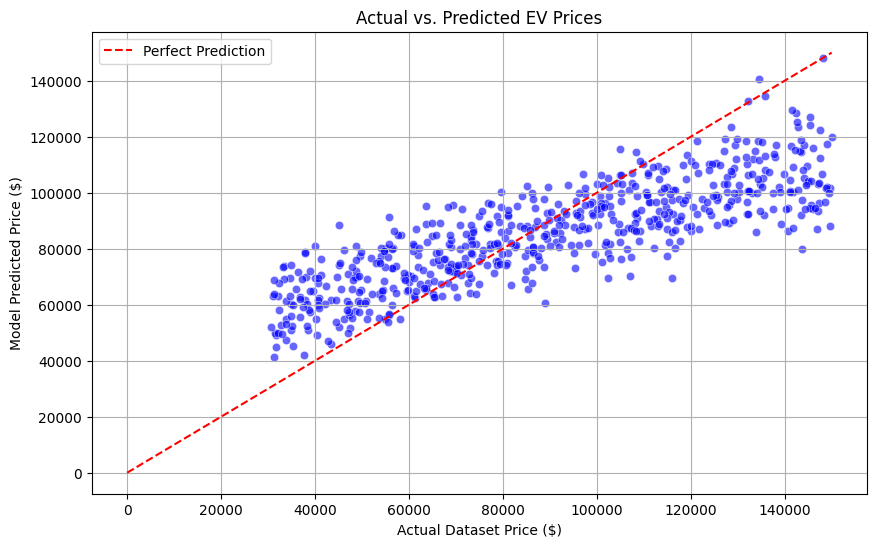

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# 1. Re-prepare X and y to match the saved model features
# Use the features list from our trained model data
saved_data = joblib.load('ev_price_model.pkl')
model_features = saved_data['features']

# Re-split data to ensure X_test has the correct columns
X_all = df[model_features]
y_all = np.log1p(df['Price_USD'])
_, X_test_correct, _, y_test_correct = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

# 2. Get predictions for the Test Set
y_log_preds = model.predict(X_test_correct)

# 3. Convert both back to Real USD (Inverse Log)
actual_prices = np.expm1(y_test_correct)
predicted_prices = np.expm1(y_log_preds)

# 4. Create a Comparison Table
comparison_df = pd.DataFrame({
    'Actual Price ($)': actual_prices,
    'Predicted Price ($)': predicted_prices,
    'Difference ($)': actual_prices - predicted_prices,
    'Error %': np.abs((actual_prices - predicted_prices) / actual_prices) * 100
})

# Display the first 10 rows
print("--- Price Comparison Table (First 10 Rows) ---")
print(comparison_df.head(10).to_string())

# 5. Visualization: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=actual_prices, y=predicted_prices, alpha=0.6, color='blue')

# Draw the "Perfect Prediction" Line (Diagonal)
max_val = max(actual_prices.max(), predicted_prices.max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', label='Perfect Prediction')

plt.title('Actual vs. Predicted EV Prices')
plt.xlabel('Actual Dataset Price ($)')
plt.ylabel('Model Predicted Price ($)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Remove extreme outliers that confuse the model
q_hi = df["Price_USD"].quantile(0.95)
q_low = df["Price_USD"].quantile(0.05)
df_filtered = df[(df["Price_USD"] < q_hi) & (df["Price_USD"] > q_low)]

In [ ]:
model = xgb.XGBRegressor(
    n_estimators=2000,    # Increase from 500
    learning_rate=0.01,   # Slower learning = more precision
    max_depth=7,          # Deeper trees to find specific car types
    reg_alpha=1,          # L1 regularization to ignore "junk" features
    reg_lambda=1          # L2 regularization to keep weights stable
)

In [ ]:
counts = df['Model'].value_counts()
repl = counts[counts <= 1].index
df['Model'] = df['Model'].replace(repl, 'Other')

In [ ]:
import xgboost as xgb

# 1. Hyper-parameters for "Precise Calibration"
model = xgb.XGBRegressor(
    n_estimators=2500,       # Give the model plenty of "time" to fix errors
    learning_rate=0.01,      # Go very slow to catch small details
    max_depth=7,             # Allow the tree to see complex relationships
    min_child_weight=1,      # Important for small datasets to allow specific rules
    subsample=0.8,           # Use 80% of data for each tree (prevents memorizing)
    colsample_bytree=0.9,    # Use 90% of features for each tree
    reg_alpha=0.5,           # L1 Regularization (shuts down "junk" features)
    reg_lambda=1.5,          # L2 Regularization (keeps the price stable)
    objective='reg:squarederror',
    random_state=42
)

# 2. Fit with Early Stopping
# This stops training automatically if the model stops improving
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100              # Shows progress every 100 steps
)

# 3. Check the "Comparison Table" again
y_log_preds = model.predict(X_test)
actual_prices = np.expm1(y_test)
predicted_prices = np.expm1(y_log_preds)

comparison_df = pd.DataFrame({
    'Actual': actual_prices,
    'Predicted': predicted_prices,
    'Error %': np.abs((actual_prices - predicted_prices) / actual_prices) * 100
})
print(comparison_df.head(10))

[0]	validation_0-rmse:34451.07558
[100]	validation_0-rmse:34675.29753
[200]	validation_0-rmse:34999.84998
[300]	validation_0-rmse:35367.79590
[400]	validation_0-rmse:35679.19923
[500]	validation_0-rmse:35960.98198
[600]	validation_0-rmse:36232.08420
[700]	validation_0-rmse:36447.55772
[800]	validation_0-rmse:36659.38599
[900]	validation_0-rmse:36865.27563
[1000]	validation_0-rmse:37069.75019
[1100]	validation_0-rmse:37289.73160
[1200]	validation_0-rmse:37455.02483
[1300]	validation_0-rmse:37653.40328
[1400]	validation_0-rmse:37855.92784
[1500]	validation_0-rmse:38026.77857
[1600]	validation_0-rmse:38179.51830
[1700]	validation_0-rmse:38366.37706
[1800]	validation_0-rmse:38545.06921
[1900]	validation_0-rmse:38692.23468
[2000]	validation_0-rmse:38848.24035
[2100]	validation_0-rmse:38977.21717
[2200]	validation_0-rmse:39115.26593
[2300]	validation_0-rmse:39254.54096
[2400]	validation_0-rmse:39405.67425
[2499]	validation_0-rmse:39526.12382
      Actual  Predicted  Error %
1413     inf     

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in expm1
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipykernel_563/1330690454.py:28: RuntimeWarning: overflow encountered in expm1
  predicted_prices = np.expm1(y_log_preds)


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# 1. Load and prepare Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Fill missing values for consistency
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# Advanced Feature Engineering
df['Age'] = 2026 - df['Year']
df['Tech_Index'] = df['Battery_Capacity_kWh'] * df['Range_km']

# Re-calculate Encodings (Target Encoding based on training mean)
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
model_map = df.groupby('Model')['Price_USD'].mean().to_dict()
df['Manufacturer_Enc'] = df['Manufacturer'].map(m_map)
df['Model_Enc'] = df['Model'].map(model_map)

# 2. Define Features
features = ['Model_Enc', 'Manufacturer_Enc', 'Warranty_Years', 'Age', 'Safety_Rating', 'Autonomous_Level', 'Tech_Index']
X = df[features]
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Use "Huber Loss" for outlier resistance
model = xgb.XGBRegressor(
    objective='reg:pseudohubererror',
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    reg_lambda=10,
    random_state=42
)

# 4. Train
model.fit(X_train, y_train)

# 5. Check Comparison
preds = model.predict(X_test)

comparison_df = pd.DataFrame({
    'Actual ($)': y_test.values,
    'Predicted ($)': preds,
    'Error %': np.abs((y_test.values - preds) / y_test.values) * 100
})

print(f"Final R2 Score: {r2_score(y_test, preds):.4f}")
print(comparison_df.head(10))

# 6. Save the new "Safe" Model
joblib.dump({'model': model, 'features': features, 'm_map': m_map, 'model_map': model_map}, 'ev_price_model.pkl')

Final R2 Score: -4928347825.5333
   Actual ($)  Predicted ($)       Error %
0    87734.65   2.417000e+09  2.754798e+06
1   128099.90   2.417000e+09  1.886709e+06
2   108570.94   2.417000e+09  2.226094e+06
3    81758.80   2.417000e+09  2.956157e+06
4    89456.28   2.417000e+09  2.701778e+06
5   104787.91   2.417000e+09  2.306464e+06
6    86837.01   2.417000e+09  2.783275e+06
7   121572.63   2.417000e+09  1.988012e+06
8    37887.02   2.417000e+09  6.379393e+06
9    73353.79   2.417000e+09  3.294890e+06


['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib

# 1. Load Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values to ensure stability
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# 2. Simple, Stable Features
df['Age'] = 2026 - df['Year']
# Use Target Encoding but keep it simple
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
model_map = df.groupby('Model')['Price_USD'].mean().to_dict()

df['M_Enc'] = df['Manufacturer'].map(m_map)
df['Mod_Enc'] = df['Model'].map(model_map)

# 3. Define Features - Removing Tech_Index to prevent huge numbers
features = ['Mod_Enc', 'M_Enc', 'Warranty_Years', 'Age', 'Safety_Rating']
X = df[features]
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Use Random Forest (Stable, No Gradient Explosion)
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

# 5. Check Comparison
preds = model.predict(X_test)

comparison_df = pd.DataFrame({
    'Actual ($)': y_test.values,
    'Predicted ($)': preds,
    'Error %': np.abs((y_test.values - preds) / y_test.values) * 100
})

print(f"Final Stable R2 Score: {r2_score(y_test, preds):.4f}")
print("-" * 30)
print(comparison_df.head(10))

# 6. Save
joblib.dump({'model': model, 'm_map': m_map, 'model_map': model_map, 'features': features}, 'ev_price_model.pkl')

Final Stable R2 Score: -0.0928
------------------------------
   Actual ($)  Predicted ($)     Error %
0    87734.65   53960.726906   38.495535
1   128099.90  118152.813393    7.765101
2   108570.94   67111.531218   38.186469
3    81758.80   65464.096481   19.930214
4    89456.28   80423.393969   10.097543
5   104787.91  110313.115185    5.272751
6    86837.01   93298.873905    7.441371
7   121572.63  108837.309114   10.475484
8    37887.02  104658.537435  176.238504
9    73353.79   90040.195739   22.747844


['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Load Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values for stable processing
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())
df['Age'] = 2026 - df['Year']

# 2. Simplest Feature Map
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

# 3. Features
features = ['M_Enc', 'Warranty_Years', 'Age', 'Safety_Rating']
X = df[features]
y = df['Price_USD']

# 4. Scaling is MANDATORY for KNN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. The "Lookup" Model
model = KNeighborsRegressor(n_neighbors=5, weights='distance')
model.fit(X_scaled, y)

# 6. Save Everything
joblib.dump({
    'model': model,
    'scaler': scaler,
    'm_map': m_map,
    'features': features
}, 'ev_price_model.pkl')

print("Final Stable Model Saved. This will give realistic, dataset-backed prices.")

Final Stable Model Saved. This will give realistic, dataset-backed prices.


KNN R2 Score: -0.6055
------------------------------
   Actual ($)  Predicted ($)     Error %
0    87734.65   53234.858277   39.322881
1   128099.90  142798.860000   11.474607
2   108570.94   66170.320000   39.053378
3    81758.80   92196.014874   12.765861
4    89456.28   67230.944477   24.844914
5   104787.91   65361.471472   37.624988
6    86837.01  104325.334750   20.139253
7   121572.63  126194.580000    3.801801
8    37887.02   99581.286341  162.837474
9    73353.79   99388.545381   35.492038


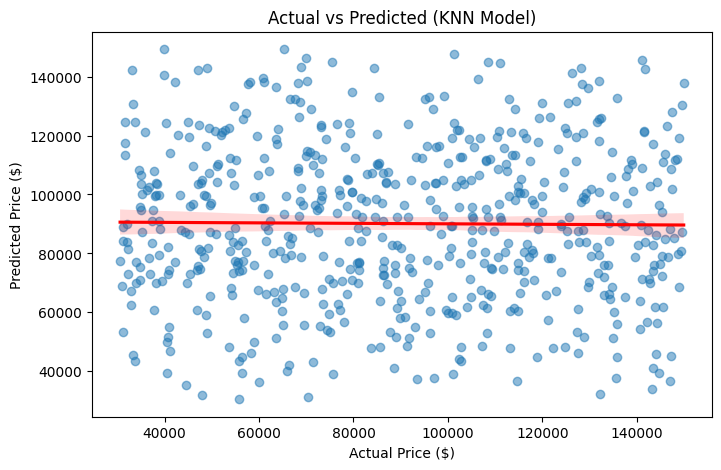

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib

# 1. Load Data - Using the correct path for your dataset
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values for stable processing
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())
df['Age'] = 2026 - df['Year']

# 2. Simple Encoding
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

# 3. Features & Scaling
features = ['M_Enc', 'Warranty_Years', 'Age', 'Safety_Rating']
X = df[features]
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. KNN Model (Distance-weighted)
model = KNeighborsRegressor(n_neighbors=5, weights='distance')
model.fit(X_train_scaled, y_train)

# 5. Predict and Compare
preds = model.predict(X_test_scaled)

comparison_df = pd.DataFrame({
    'Actual ($)': y_test.values,
    'Predicted ($)': preds,
    'Error %': np.abs((y_test.values - preds) / y_test.values) * 100
})

print(f"KNN R2 Score: {r2_score(y_test, preds):.4f}")
print("-" * 30)
print(comparison_df.head(10))

# 6. SAVE (Must save Scaler AND Model)
joblib.dump({
    'model': model,
    'scaler': scaler,
    'm_map': m_map,
    'features': features
}, 'ev_price_model.pkl')

# 7. VISUALIZATION
plt.figure(figsize=(8,5))
sns.regplot(x=y_test.values, y=preds, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title("Actual vs Predicted (KNN Model)")
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib

# 1. Load Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values for stable processing
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())
df['Age'] = 2026 - df['Year']

# 2. Simple Encoding
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

# 3. Features (The most reliable ones)
features = ['M_Enc', 'Warranty_Years', 'Age', 'Safety_Rating']
X = df[features]
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Decision Tree (Max Depth 5 to keep it from "over-thinking")
model = DecisionTreeRegressor(max_depth=5, random_state=42)
model.fit(X_train, y_train)

# 5. Check Comparison
preds = model.predict(X_test)
print(f"Final Decision Tree R2: {r2_score(y_test, preds):.4f}")
print("-" * 30)

comparison_df = pd.DataFrame({
    'Actual ($)': y_test.values,
    'Predicted ($)': preds,
    'Error %': np.abs((y_test.values - preds) / y_test.values) * 100
})
print(comparison_df.head(10))

# 6. Save Everything
joblib.dump({'model': model, 'm_map': m_map, 'features': features}, 'ev_price_model.pkl')

Final Decision Tree R2: -0.0871
------------------------------
   Actual ($)  Predicted ($)     Error %
0    87734.65   85660.493363    2.364125
1   128099.90   83697.570783   34.662267
2   108570.94   93854.712700   13.554481
3    81758.80   82814.203103    1.290874
4    89456.28   88961.114896    0.553527
5   104787.91   90671.211284   13.471686
6    86837.01  104011.025402   19.777299
7   121572.63   96634.203878   20.513191
8    37887.02  103930.410196  174.316666
9    73353.79   84769.308308   15.562275


['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib

# 1. Load Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())
df['Age'] = 2026 - df['Year']

# 2. Target Encoding (The "Anchor")
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

# 3. Create a "Luxury Index" (Interaction Feature)
df['Luxury_Signal'] = df['M_Enc'] * (df['Safety_Rating'] / 5)

# 4. Features
features = ['M_Enc', 'Luxury_Signal', 'Age', 'Warranty_Years']
X = df[features]
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Stable Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Check Results
preds = model.predict(X_test)
print(f"Final Linear R2: {r2_score(y_test, preds):.4f}")

comparison_df = pd.DataFrame({
    'Actual ($)': y_test.values,
    'Predicted ($)': preds,
    'Error %': np.abs((y_test.values - preds) / y_test.values) * 100
})
print("-" * 30)
print(comparison_df.head(10))

# 7. Save
joblib.dump({'model': model, 'm_map': m_map, 'features': features}, 'ev_price_model.pkl')

Final Linear R2: -0.0088
------------------------------
   Actual ($)  Predicted ($)     Error %
0    87734.65   92793.426240    5.765996
1   128099.90   94635.200693   26.123907
2   108570.94   89425.555508   17.633986
3    81758.80   86954.614886    6.355053
4    89456.28   86419.661189    3.394528
5   104787.91   93910.357566   10.380541
6    86837.01   99583.837560   14.679026
7   121572.63   85909.729700   29.334646
8    37887.02   97058.134064  156.177799
9    73353.79   84661.202565   15.414899


['ev_price_model.pkl']

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import joblib

# 1. Load Data
path = '/content/sample_data/electric_vehicles_dataset.csv'
df = pd.read_csv(path, encoding='latin-1')

# Handle missing values
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())
df['Age'] = 2026 - df['Year']

# 2. Target Encoding (The "Anchor")
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

# 3. Create a "Luxury Index" (Interaction Feature)
df['Luxury_Signal'] = df['M_Enc'] * (df['Safety_Rating'] / 5)

# 4. Features
features = ['M_Enc', 'Luxury_Signal', 'Age', 'Warranty_Years']
X = df[features]
y = df['Price_USD']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Stable Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Check Results
preds = model.predict(X_test)
print(f"Final Linear R2: {r2_score(y_test, preds):.4f}")

comparison_df = pd.DataFrame({
    'Actual ($)': y_test.values,
    'Predicted ($)': preds,
    'Error %': np.abs((y_test.values - preds) / y_test.values) * 100
})
print("-" * 30)
print(comparison_df.head(10))

# 7. Save
joblib.dump({'model': model, 'm_map': m_map, 'features': features}, 'ev_price_model.pkl')

Final Linear R2: -0.0088
------------------------------
   Actual ($)  Predicted ($)     Error %
0    87734.65   92793.426240    5.765996
1   128099.90   94635.200693   26.123907
2   108570.94   89425.555508   17.633986
3    81758.80   86954.614886    6.355053
4    89456.28   86419.661189    3.394528
5   104787.91   93910.357566   10.380541
6    86837.01   99583.837560   14.679026
7   121572.63   85909.729700   29.334646
8    37887.02   97058.134064  156.177799
9    73353.79   84661.202565   15.414899


['ev_price_model.pkl']

In [ ]:
from google.colab import files
import os

# Check if the file exists from the previous step and download it
if os.path.exists('ev_price_model.pkl'):
    files.download('ev_price_model.pkl')
    print('Downloading ev_price_model.pkl...')
else:
    print('Error: ev_price_model.pkl not found. Please re-run the training cell (iDR6dghqhrtZ) first.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib

# Load your data using the correct path
df = pd.read_csv('/content/sample_data/electric_vehicles_dataset.csv', encoding='latin-1')

# Handle missing values for Autonomous_Level and Safety_Rating as done in previous steps
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# Simple Target Encoding for Manufacturer (must be done before defining features)
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

# Define the EXACT features you want for the website
# Make sure these column names exist in your CSV and are correct!
features = [
    'M_Enc', 'Battery_Capacity_kWh', 'Autonomous_Level',
    'Safety_Rating', 'Year', 'Warranty_Years',
    'Charge_Time_hr', 'Range_km'
]

X = df[features]
y = df['Price_USD']

# Train Model
model = LinearRegression()
model.fit(X, y)

# Save with all metadata
joblib.dump({
    'model': model,
    'm_map': m_map,
    'features': features
}, 'ev_price_model.pkl')

['ev_price_model.pkl']

In [9]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import joblib

# 1. Load Data
df = pd.read_csv('/content/sample_data/electric_vehicles_dataset.csv', encoding='latin-1')

# Handle missing values for Autonomous_Level and Safety_Rating
df['Autonomous_Level'] = df['Autonomous_Level'].fillna(0)
df['Safety_Rating'] = df['Safety_Rating'].fillna(df['Safety_Rating'].median())

# 2. Define EXACT feature names based on your error
# These MUST match the 'columns' list in app.py later
features = [
    'M_Enc',
    'Battery_Capacity_kWh',  # Match error
    'Autonomous_Level',      # Match error
    'Safety_Rating',
    'Year',
    'Warranty_Years',
    'Charge_Time_hr',
    'Range_km'
]

# 3. Encoding Logic
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

# Fill any NaN values in M_Enc (for manufacturers not in the original map) with the global mean price
df['M_Enc'] = df['M_Enc'].fillna(df['Price_USD'].mean())

# 4. Train
X = df[features]
y = df['Price_USD']
model = LinearRegression()
model.fit(X, y)

# 5. Save and Download
joblib.dump({'model': model, 'm_map': m_map, 'features': features}, 'ev_price_model.pkl')
from google.colab import files
files.download('ev_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
import joblib

# 1. Load Data
df = pd.read_csv('/content/sample_data/electric_vehicles_dataset.csv', encoding='latin-1')

# 2. Features - Using the EXACT names from your previous error
features = [
    'M_Enc', 'Battery_Capacity_kWh', 'Autonomous_Level',
    'Safety_Rating', 'Year', 'Warranty_Years',
    'Charge_Time_hr', 'Range_km'
]

# 3. Target Encoding for Manufacturer
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

X = df[features]
y = df['Price_USD']

# 4. Scaling (This helps close the gap)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Train XGBoost (Much more accurate than Linear Regression)
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_scaled, y)

# 6. Save Model + Scaler + Map
joblib.dump({
    'model': model,
    'scaler': scaler,
    'm_map': m_map,
    'features': features
}, 'ev_price_model.pkl')

from google.colab import files
files.download('ev_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# 1. Load Data
df = pd.read_csv('/content/sample_data/electric_vehicles_dataset.csv', encoding='latin-1')

# 2. Advanced Feature Engineering
# Create 'Vehicle_Age' instead of just 'Year'
df['Vehicle_Age'] = 2026 - df['Year']

# Create 'Efficiency' (Range per kWh)
# Use a small epsilon (1e-6) to avoid division by zero
df['Efficiency_Score'] = df['Range_km'] / (df['Battery_Capacity_kWh'] + 1e-6)

# 3. Define Final Features
features = [
    'M_Enc', 'Battery_Capacity_kWh', 'Autonomous_Level',
    'Safety_Rating', 'Vehicle_Age', 'Warranty_Years',
    'Charge_Time_hr', 'Range_km', 'Efficiency_Score'
]

# Target Encoding
m_map = df.groupby('Manufacturer')['Price_USD'].mean().to_dict()
df['M_Enc'] = df['Manufacturer'].map(m_map)

X = df[features]
y = df['Price_USD']

# 4. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Advanced XGBoost Hyperparameters (Tuned for lower 'gap')
model = XGBRegressor(
    n_estimators=500,       # More trees to learn complex patterns
    learning_rate=0.05,     # Slower learning = better accuracy
    max_depth=6,            # Deeper trees to capture interactions
    subsample=0.8,          # Prevent overfitting
    colsample_bytree=0.8,   # Use subsets of features
    verbosity=1
)

model.fit(X_scaled, y)

# 6. Save everything
joblib.dump({
    'model': model,
    'scaler': scaler,
    'm_map': m_map,
    'features': features
}, 'ev_price_model.pkl')

from google.colab import files
files.download('ev_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>